In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
import piplite
await piplite.install('openpyxl')

In [ ]:
transactions = pd.read_excel("QVI_transaction_data.xlsx")
customers = pd.read_csv("QVI_purchase_behaviour.csv")

In [10]:
# Merge the transaction and customer datasets together
data = pd.merge(transactions, customers, on="LYLTY_CARD_NBR", how="left")

# Create the unit price column
data["PRICE_PER_UNIT"] = data["TOT_SALES"] / data["PROD_QTY"]

In [13]:
import piplite
await piplite.install('seaborn')

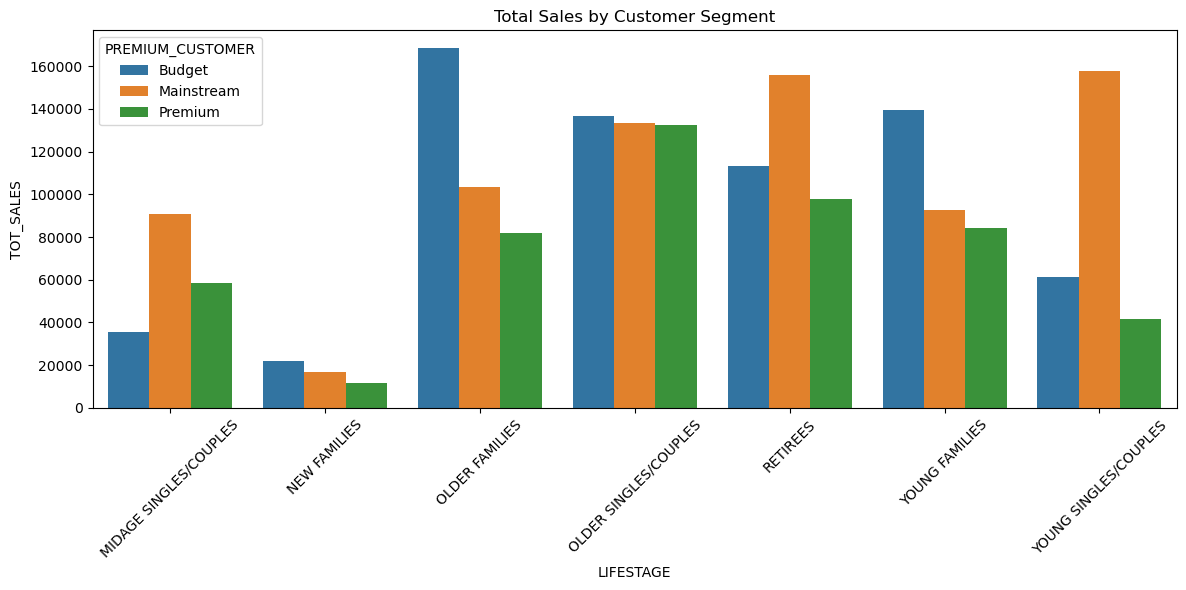

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns 

sales_segment = data.groupby(["LIFESTAGE", "PREMIUM_CUSTOMER"])["TOT_SALES"].sum().reset_index()

plt.figure(figsize=(12,6))
sns.barplot(data=sales_segment, x="LIFESTAGE", y="TOT_SALES", hue="PREMIUM_CUSTOMER")
plt.xticks(rotation=45)
plt.title("Total Sales by Customer Segment")
plt.tight_layout()
plt.savefig("total_sales_by_segment.png", dpi=300)
plt.show()

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import piplite

In [16]:
await piplite.install('openpyxl')
await piplite.install('seaborn')

In [17]:
plt.style.use('default')
sns.set_theme(style="whitegrid")

In [18]:
transactions = pd.read_excel("QVI_transaction_data.xlsx")
customers = pd.read_csv("QVI_purchase_behaviour.csv")

In [19]:
transactions["DATE"] = pd.to_datetime(transactions["DATE"], origin="1899-12-30", unit="D")
transactions = transactions[~transactions["PROD_NAME"].str.lower().str.contains("salsa")]
transactions = transactions[transactions["LYLTY_CARD_NBR"] != 226000]

In [20]:
transactions["PACK_SIZE"] = transactions["PROD_NAME"].str.extract(r'(\d+)').astype(int)
transactions["BRAND"] = transactions["PROD_NAME"].str.split().str[0].replace({"RED": "RRD"})
data = pd.merge(transactions, customers, on="LYLTY_CARD_NBR", how="left")
data["PRICE_PER_UNIT"] = data["TOT_SALES"] / data["PROD_QTY"]

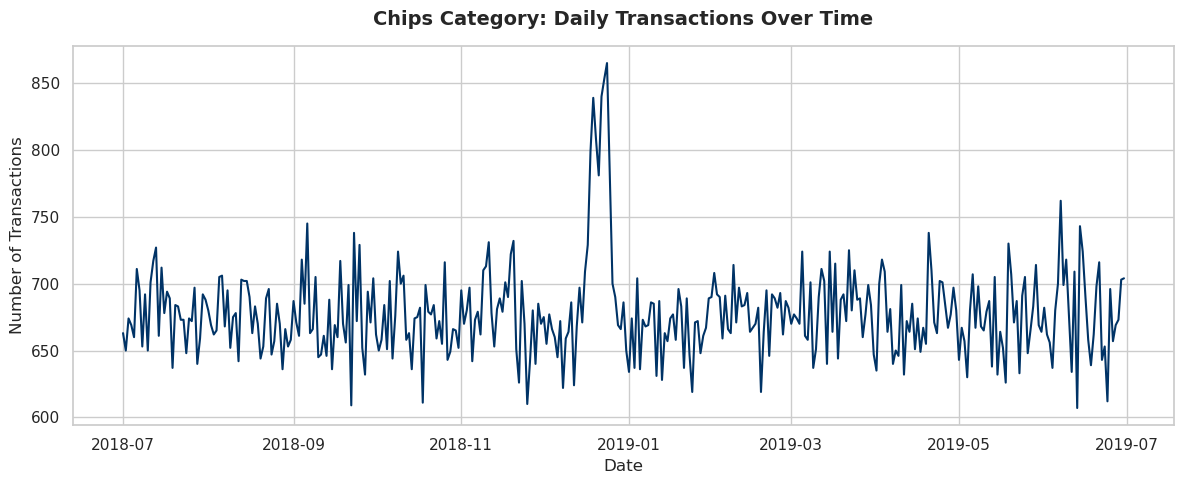

In [21]:
daily_transactions = data.groupby("DATE").size().reset_index(name="TRANSACTIONS")

plt.figure(figsize=(12, 5))
plt.plot(daily_transactions["DATE"], daily_transactions["TRANSACTIONS"], color='#003366', linewidth=1.5)
plt.title("Chips Category: Daily Transactions Over Time", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Number of Transactions", fontsize=12)
plt.tight_layout()
plt.savefig("category_transactions_timeline.png", dpi=300)
plt.show()

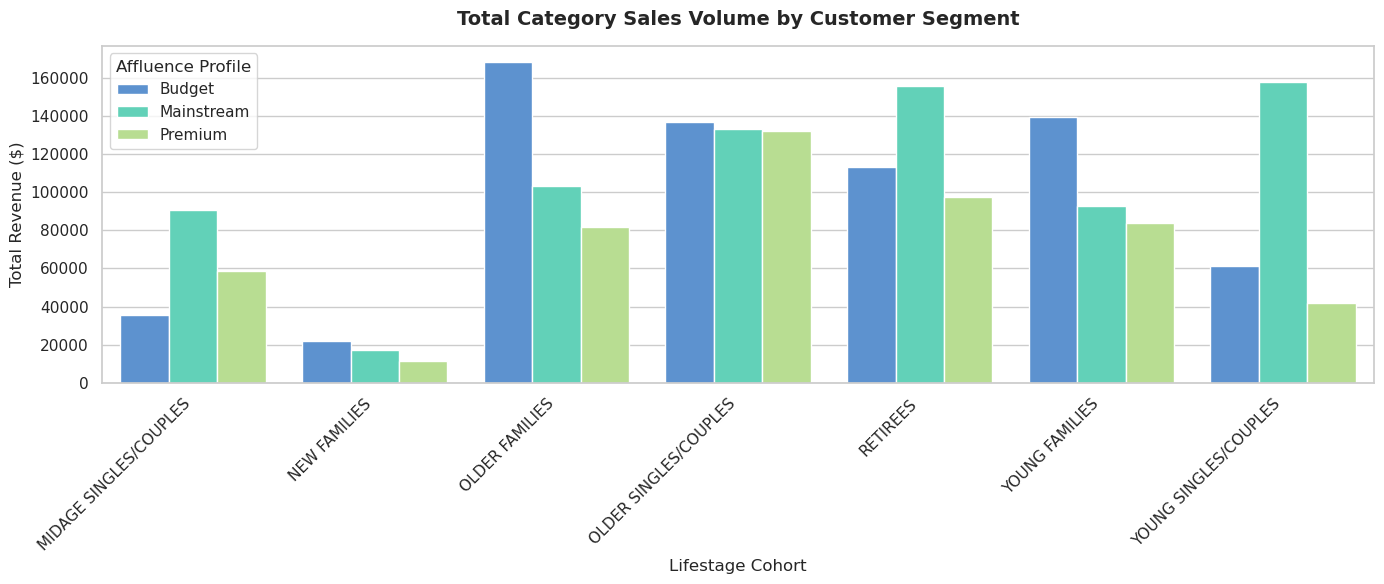

In [22]:
ales_segment = data.groupby(["LIFESTAGE", "PREMIUM_CUSTOMER"])["TOT_SALES"].sum().reset_index()

plt.figure(figsize=(14, 6))
sns.barplot(
    data=sales_segment, 
    x="LIFESTAGE", 
    y="TOT_SALES", 
    hue="PREMIUM_CUSTOMER", 
    palette=["#4A90E2", "#50E3C2", "#B8E986"]
)
plt.xticks(rotation=45, ha='right')
plt.title("Total Category Sales Volume by Customer Segment", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Lifestage Cohort", fontsize=12)
plt.ylabel("Total Revenue ($)", fontsize=12)
plt.legend(title="Affluence Profile")
plt.tight_layout()
plt.savefig("total_sales_by_segment.png", dpi=300)
plt.show()

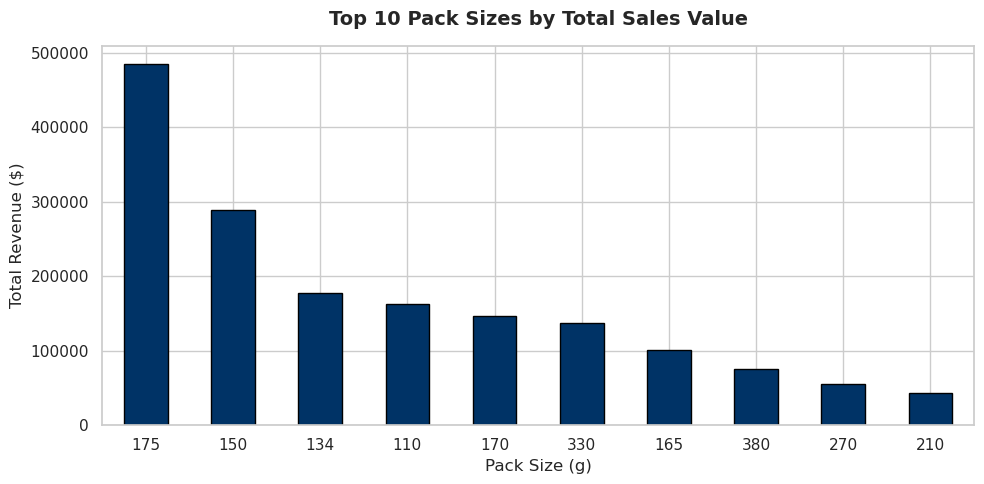

In [23]:
pack_sales = data.groupby("PACK_SIZE")["TOT_SALES"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
pack_sales.plot(kind="bar", color="#003366", edgecolor='black')
plt.title("Top 10 Pack Sizes by Total Sales Value", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Pack Size (g)", fontsize=12)
plt.ylabel("Total Revenue ($)", fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("top_pack_sizes.png", dpi=300)
plt.show()